Training on 1304 rows. Testing on 218 rows (2021 data).
R2 Score (2021): 0.94
MAE (2021): 0.152

Feature Importance (2021 Test Set):
                   Feature  Importance_Mean  Importance_Std
5        Prev_Total_Medals         1.474381        0.091143
8                  Is_Host         0.126406        0.053120
4         Lagged_Team_Size         0.018465        0.003065
1              Log_Pop_t_1         0.013494        0.008440
6                  hdi_t_1         0.000200        0.001061
3  perc_athletic_prime_t_1        -0.000639        0.003959
7                  gdi_t_1        -0.000735        0.003667
2         GDP_Growth_Cycle        -0.001140        0.000979
0              Log_GDP_t_1        -0.004810        0.001160


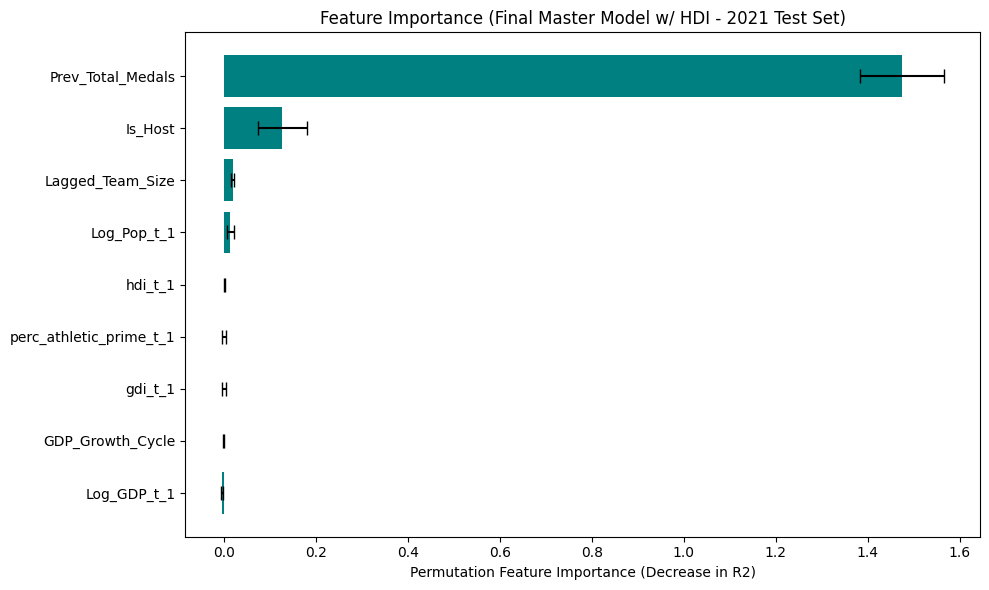

In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, r2_score

# Load the dataset
df = pd.read_csv('dataset_thesis_new_hdi_v8.csv')

# Ensure chronological sorting for lags
df = df.sort_values(['iso_code_mapped', 'year'])

#  t-1 Lags
for col in ['GDP_merged', 'population', 'hdi', 'gdi', 'perc_athletic_prime']:
    df[f'{col}_t_1'] = df.groupby('iso_code_mapped')[col].shift(1)

#  GDP growth cycle (t-1 vs t-4 approx)
df['GDP_t_4'] = df.groupby('iso_code_mapped')['GDP_merged'].shift(4)
df['GDP_Growth_Cycle'] = ((df['GDP_merged_t_1'] - df['GDP_t_4']) / df['GDP_t_4']) * 100

# 3. Filter to Olympic years and shift cyclical variables (Team Size, Previous Medals)
olympic_years = [1996, 2000, 2004, 2008, 2012, 2016, 2021, 2024]
oly = df[df['year'].isin(olympic_years)].copy()
oly = oly.sort_values(['iso_code_mapped', 'year'])

oly['Lagged_Team_Size'] = oly.groupby('iso_code_mapped')['Team_Size'].shift(1)
oly['Prev_Total_Medals'] = oly.groupby('iso_code_mapped')['Total'].shift(1)

#  Target variable: Medal Share %
global_medals = oly.groupby('year')['Total'].sum().rename('Global_Total')
oly = oly.merge(global_medals, on='year')
oly['Medal_Share_Pct'] = (oly['Total'] / oly['Global_Total']) * 100

# Log scale for massive absolute variables
oly['Log_GDP_t_1'] = np.log10(oly['GDP_merged_t_1'])
oly['Log_Pop_t_1'] = np.log10(oly['population_t_1'])

#  Clean up missing values for required features
final_features = [
    'Log_GDP_t_1', 'Log_Pop_t_1', 'GDP_Growth_Cycle', 
    'perc_athletic_prime_t_1', 'Lagged_Team_Size', 'Prev_Total_Medals', 
    'hdi_t_1', 'gdi_t_1', 'Is_Host'
]

# Impute
for f in final_features:
    if f in ['Lagged_Team_Size', 'Prev_Total_Medals']:
        oly[f] = oly[f].fillna(0)  # Assume 0 if they didn't participate previously
    else:
        oly[f] = oly[f].fillna(oly[f].mean())

# Filter rows where target or absolute core vars might still be NaN
oly_clean = oly.dropna(subset=['Medal_Share_Pct', 'Log_GDP_t_1']).copy()

# Train/Test Split (Train < 2021, Test == 2021)
train = oly_clean[oly_clean['year'] < 2021]
test = oly_clean[oly_clean['year'] == 2021]

X_train = train[final_features]
y_train = train['Medal_Share_Pct']
X_test = test[final_features]
y_test = test['Medal_Share_Pct']

print(f"Training on {len(X_train)} rows. Testing on {len(X_test)} rows (2021 data).")

#  Train RF
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
print(f"R2 Score (2021): {r2_score(y_test, y_pred):.2f}")
print(f"MAE (2021): {mean_absolute_error(y_test, y_pred):.3f}")

#  Permutation Importance
perm = permutation_importance(rf, X_test, y_test, n_repeats=30, random_state=42, n_jobs=-1)
imp = pd.DataFrame({
    'Feature': final_features,
    'Importance_Mean': perm.importances_mean,
    'Importance_Std': perm.importances_std
}).sort_values('Importance_Mean', ascending=False)

print("\nFeature Importance (2021 Test Set):")
print(imp)

# Generate Plot
plt.figure(figsize=(10, 6))
imp_sorted = imp.sort_values(by='Importance_Mean', ascending=True)
plt.barh(imp_sorted['Feature'], imp_sorted['Importance_Mean'], xerr=imp_sorted['Importance_Std'], color='teal', capsize=5)
plt.xlabel('Permutation Feature Importance (Decrease in R2)')
plt.title('Feature Importance (Final Master Model w/ HDI - 2021 Test Set)')
plt.tight_layout()
plt.savefig('rf_2021_hdi.png')

In [4]:
#COMPARISON 2021 MEDALS PREDCTED VS ACTUAL

test_pred = rf.predict(X_test)
test_results = test.copy()
test_results['Predicted_Share_Pct'] = test_pred

# Convert back to raw medals (using 2021 global total)

total_2021_medals = test_results['Global_Total'].iloc[0]
test_results['Predicted_Total_Medals'] = (test_pred / 100) * total_2021_medals

# Cleanup 
comp_table = test_results[['iso_code_mapped', 'Total', 'Predicted_Total_Medals', 'Medal_Share_Pct', 'Predicted_Share_Pct']].copy()
comp_table.columns = ['Country', 'Actual_Medals', 'Predicted_Medals', 'Actual_Share_Pct', 'Predicted_Share_Pct']
comp_table['Predicted_Medals'] = comp_table['Predicted_Medals'].round(1)
comp_table['Predicted_Share_Pct'] = comp_table['Predicted_Share_Pct'].round(2)
comp_table['Actual_Share_Pct'] = comp_table['Actual_Share_Pct'].round(2)

# Sort by actual medals descending to show top countries
comp_table = comp_table.sort_values('Actual_Medals', ascending=False).head(20)
print(comp_table.to_string(index=False))

Country  Actual_Medals  Predicted_Medals  Actual_Share_Pct  Predicted_Share_Pct
    USA            113             127.1             10.46                11.76
    CHN             88             103.0              8.15                 9.54
    RUS             71              77.6              6.57                 7.19
    GBR             65              69.6              6.02                 6.45
    JPN             58              52.0              5.37                 4.82
    AUS             46              29.9              4.26                 2.77
    ITA             40              34.6              3.70                 3.20
    DEU             37              48.0              3.43                 4.45
    NLD             36              22.3              3.33                 2.06
    FRA             33              49.2              3.06                 4.56
    CAN             24              22.4              2.22                 2.07
    BRA             21              27.2